<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/15_TSLA_Regularization_Ridge_Lasso_ElasticNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실습 15. 시계열 예측의 과소적합·과적합과 정규화

**주제:** Underfitting / Good Fit / Overfitting → Ridge (L2) → Lasso (L1) → Elastic Net (L1 + L2)

**목표:** 테슬라(TSLA)의 **다음 거래일 종가**를 예측하면서 OLS와 정규화 회귀를 공정하게 비교합니다.

**학습 순서:** 내용 설명 → 수식 → 실습 코드 → 결과 → 해석

> 설계 원칙: 데이터 누수 방지 / 시간순 학습·검증·테스트 / 하이퍼파라미터는 검증기간에서만 선택 / Naïve 기준모형 / 동일 평가일·동일 목표변수.
>
> 주의: 주가를 정확히 맞히는 것이 목적이 아니라 **과적합과 일반화**의 차이를 이해하는 교육용 실습입니다.

## 0. 환경 설정

- Google Colab에서 **런타임 → 모두 실행**을 사용하세요.
- `yfinance`로 Yahoo Finance의 TSLA 일별 가격을 다운로드합니다. 외부 네트워크 연결이 필요합니다.
- 그래프의 글자 깨짐을 방지하기 위해 **영어 제목·범례**와 **흰 배경**을 사용합니다.
- `auto_adjust=True`는 가격의 분할·배당 등 조정을 반영합니다. 가격 시계열 분석 시 조정 기준을 일관되게 유지합니다.

In [1]:
%pip -q install yfinance scikit-learn matplotlib pandas numpy

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from IPython.display import display

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams.update({'figure.facecolor':'white', 'axes.facecolor':'white',
                     'savefig.facecolor':'white', 'font.size':10})
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Underfitting / Good Fit / Overfitting 이해하기

- **Underfitting(과소적합):** 모델이 지나치게 단순하여 학습 자료의 핵심 패턴도 설명하지 못함 (높은 편향).
- **Good Fit(적절한 적합):** 데이터의 구조를 포착하면서 새로운 데이터에도 비교적 잘 일반화함.
- **Overfitting(과적합):** 학습 자료의 잡음까지 학습하여 훈련 성능은 좋지만 새로운 데이터에서는 성능이 나빠질 수 있음 (높은 분산).

아래는 개념을 명확히 보여주기 위한 **합성 데이터** 그림입니다. **TSLA 실제 결과가 아닙니다.** 훈련자료만으로 각각 1차·3차·15차 다항식을 적합합니다.

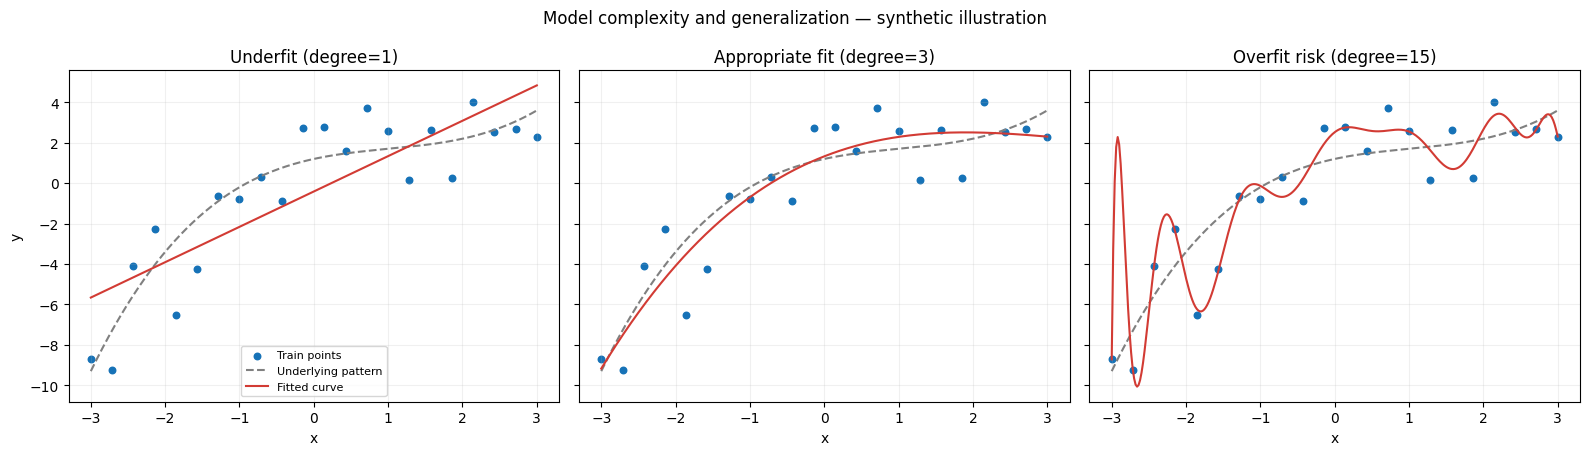

,Model,Train MSE,Validation MSE
0,Underfit (degree=1),4.620,4.060
1,Appropriate fit (degree=3),2.158,2.506
2,Overfit risk (degree=15),0.636,3.905


In [3]:
# 동일한 생성과정을 따르는 학습 점과 새로운 검증 점을 준비합니다.
rng = np.random.default_rng(RANDOM_STATE)
x_train_demo = np.linspace(-3, 3, 22)
true_fun = lambda x: 1.2 + 0.8*x - 0.45*x**2 + 0.15*x**3
train_y_demo = true_fun(x_train_demo) + rng.normal(0, 1.9, len(x_train_demo))
x_valid_demo = np.linspace(-2.85, 2.85, 80)
valid_y_demo = true_fun(x_valid_demo) + rng.normal(0, 1.9, len(x_valid_demo))
x_grid = np.linspace(-3, 3, 300)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharey=True)
fit_rows = []
for ax, degree, name in zip(axes, [1, 3, 15], ['Underfit (degree=1)', 'Appropriate fit (degree=3)', 'Overfit risk (degree=15)']):
    # 큰 차수는 수치불안정을 줄이기 위해 입력을 표준화하고 다항항을 만듭니다.
    mdl = Pipeline([('scale', StandardScaler()),
                    ('poly', PolynomialFeatures(degree, include_bias=False)),
                    ('reg', LinearRegression())])
    mdl.fit(x_train_demo.reshape(-1,1), train_y_demo)
    train_hat = mdl.predict(x_train_demo.reshape(-1,1))
    valid_hat = mdl.predict(x_valid_demo.reshape(-1,1))
    fit_rows.append([name, mean_squared_error(train_y_demo, train_hat), mean_squared_error(valid_y_demo, valid_hat)])
    ax.scatter(x_train_demo, train_y_demo, color='#1672b7', s=22, label='Train points')
    ax.plot(x_grid, true_fun(x_grid), ls='--', color='gray', label='Underlying pattern')
    ax.plot(x_grid, mdl.predict(x_grid.reshape(-1,1)), color='#d23b34', label='Fitted curve')
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.grid(alpha=.18)
axes[0].set_ylabel('y')
axes[0].legend(fontsize=8, loc='lower center')
plt.suptitle('Model complexity and generalization — synthetic illustration')
plt.tight_layout()
plt.show()
display(pd.DataFrame(fit_rows, columns=['Model', 'Train MSE', 'Validation MSE']).round(3))

### 결과 해석

- 차수가 커질수록 **훈련오차가 감소**하더라도 검증오차까지 감소하는 것은 아닙니다.
- 그림의 가운데가 개념적으로 적절한 적합의 예시입니다. 실제 최적 차수는 검증결과로 판단해야 하며, 그림만으로 항상 3차가 최적이라고 일반화할 수 없습니다.
- 고차 다항식은 경계에서 크게 진동할 수 있습니다. **높은 복잡도 = 우수한 미래 예측력**은 아닙니다.

## 2. 정규화 회귀의 원리

일반 선형회귀는 잔차제곱합을 최소화합니다. Ridge/Lasso/Elastic Net은 여기에 **회귀계수 크기에 대한 벌점**을 추가합니다. 절편은 일반적으로 벌점에서 제외합니다.

### OLS (Ordinary Least Squares)

$$
\min_{\beta_0,\beta}\ \sum_{t=1}^{n}(y_t-\beta_0-X_t^T\beta)^2
$$

### Ridge Regression — L2

$$
\min_{\beta_0,\beta}\ \frac{1}{2n}\sum_{t=1}^{n}(y_t-\beta_0-X_t^T\beta)^2+\alpha\sum_{j=1}^{p}\beta_j^2
$$

### Lasso Regression — L1

$$
\min_{\beta_0,\beta}\ \frac{1}{2n}\sum_{t=1}^{n}(y_t-\beta_0-X_t^T\beta)^2+\alpha\sum_{j=1}^{p}|\beta_j|
$$

### Elastic Net — L1 + L2

$$
\min_{\beta_0,\beta}\ \frac{1}{2n}\sum_{t=1}^{n}(y_t-\beta_0-X_t^T\beta)^2 + \alpha\rho\sum_{j=1}^{p}|\beta_j| +\frac{\alpha(1-\rho)}{2}\sum_{j=1}^{p}\beta_j^2
$$

**해석:** Ridge는 계수 크기를 줄이고, Lasso는 일부 계수를 **정확히 0**으로 만들 수 있습니다. Elastic Net은 L1/L2 성격을 함께 가집니다.

> 수식은 정규화 원리의 설명용입니다. scikit-learn의 `Ridge` 구현은 잔차항과 벌점항에 사용하는 정규화 계수 정의가 위 식과 다르므로, **모델 간 같은 수치의 alpha가 같은 벌점 강도를 의미하지 않습니다.**
>
> 스케일에 따른 벌점 편향을 막기 위해 `StandardScaler`를 각 모델의 `Pipeline` 안에 둡니다.

## 3. TSLA 실제 데이터 수집 및 예측 문제 정의

**예측 시점:** 거래일 `t` 장 마감 후 관측 가능한 변수들로 **다음 거래일 `t+1`의 종가**를 예측합니다.

- 특징변수: 당일 조정 종가, 과거 수익률, 당일까지의 이동평균과 변동성, 거래량 정보
- 목표변수: `Target_Next_Close = Close.shift(-1)`
- Naïve 기준모형: 다음 거래일의 종가를 **당일 종가**로 예측
- 동일한 행에 미래 시점의 변수를 포함하지 않습니다. 따라서 예측은 **장 마감 후 다음 거래일 종가 예측**으로 정의됩니다.

> 이 자료의 `Volume`이나 조정가격은 교육용으로 사용합니다. 실전 의사결정에서는 가격 확정·수정 시점, 기업행동 반영과 데이터 공급자의 point-in-time 제공 여부도 검토해야 합니다.

In [4]:
# 인터넷이 되는 Colab 런타임에서 실행하세요.
TICKER = 'TSLA'
START_DATE = '2018-01-01'
END_DATE = '2026-10-01'  # 종료일 미포함; 강의 재현을 위한 고정 날짜
raw = yf.download(TICKER, start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)
if raw.empty:
    raise RuntimeError('TSLA 다운로드 결과가 비었습니다. 인터넷 연결 및 기간을 확인하세요.')

# yfinance 버전에 따라 ('Close', 'TSLA') 같은 MultiIndex가 생길 수 있습니다.
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
raw = raw.sort_index()
df = raw[['Close', 'Volume']].copy().dropna()
print('Observations:', len(df), '| period:', df.index.min().date(), 'to', df.index.max().date())
display(df.head())

Observations: 2198 | period: 2018-01-02 to 2026-09-30


Price,Close,Volume
Date,,
2018-01-02,21.368668,65283000
2018-01-03,21.150000,67822500
2018-01-04,20.974667,149194500
2018-01-05,21.105333,68868000
2018-01-08,22.427334,147891000


In [5]:
# 관측일 t의 장 마감 후 계산 가능한 특징만 만듭니다.
# rolling은 현재 거래일까지의 관측만 사용합니다. 목표는 shift(-1)된 다음 거래일 종가입니다.
df['Return_1'] = df['Close'].pct_change(1)
df['Return_5'] = df['Close'].pct_change(5)
df['MA_5_Ratio'] = df['Close'] / df['Close'].rolling(5).mean() - 1
df['MA_20_Ratio'] = df['Close'] / df['Close'].rolling(20).mean() - 1
df['Volatility_10'] = df['Return_1'].rolling(10).std()
df['Volume_Ratio_5'] = df['Volume'] / df['Volume'].rolling(5).mean() - 1
# Target을 마지막에 정의하여 현재일 t와 예측 대상 t+1의 관계를 명확히 합니다.
df['Target_Next_Close'] = df['Close'].shift(-1)
FEATURES = ['Close', 'Return_1', 'Return_5', 'MA_5_Ratio',
            'MA_20_Ratio', 'Volatility_10', 'Volume_Ratio_5']
data = df[FEATURES + ['Target_Next_Close']].replace([np.inf, -np.inf], np.nan).dropna().copy()
# 원본 인덱스는 특징 관측일 t입니다; Target은 t+1 종가입니다.
assert data.index.is_monotonic_increasing
assert len(data) > 300, '관측치가 너무 적습니다. 다운로드 기간을 늘리세요.'
print('Model-ready rows:', len(data))
display(data.head(3).round(5))

Model-ready rows: 2178


Price,Close,Return_1,Return_5,MA_5_Ratio,MA_20_Ratio,Volatility_10,Volume_Ratio_5,Target_Next_Close
Date,,,,,,,,
2018-01-30,23.05467,-0.01061,-0.01976,0.00428,0.02375,0.01641,-0.09387,23.62067
2018-01-31,23.62067,0.02455,0.02434,0.02393,0.04367,0.01691,0.15253,23.28333
2018-02-01,23.28333,-0.01428,0.03439,0.00258,0.02394,0.01747,-0.14038,22.91667


## 4. 시간순 학습·검증·테스트 분리

- **Train 60%:** 회귀계수 추정
- **Validation 20%:** Ridge/Lasso/Elastic Net의 `alpha`, Elastic Net의 `l1_ratio` 선택
- **Test 20%:** 최종 한 번만 성능 평가

여기서는 거래일 `t`의 특징으로 `t+1` 값을 예측하므로, 학습경계의 바로 직전 행은 목표값이 다음 구간 첫날에 속할 수 있습니다. **경계마다 한 관측치씩 제거(purge)**하여 훈련·검증 대상기간 겹침을 방지합니다.

**중요:** 테스트에 있는 정답을 참조하여 하이퍼파라미터를 바꾸지 않습니다.

Train: 1305 2018-01-30 - 2023-04-05
Valid: 435 2023-04-10 - 2024-12-30
Test : 436 2025-01-02 - 2026-09-29


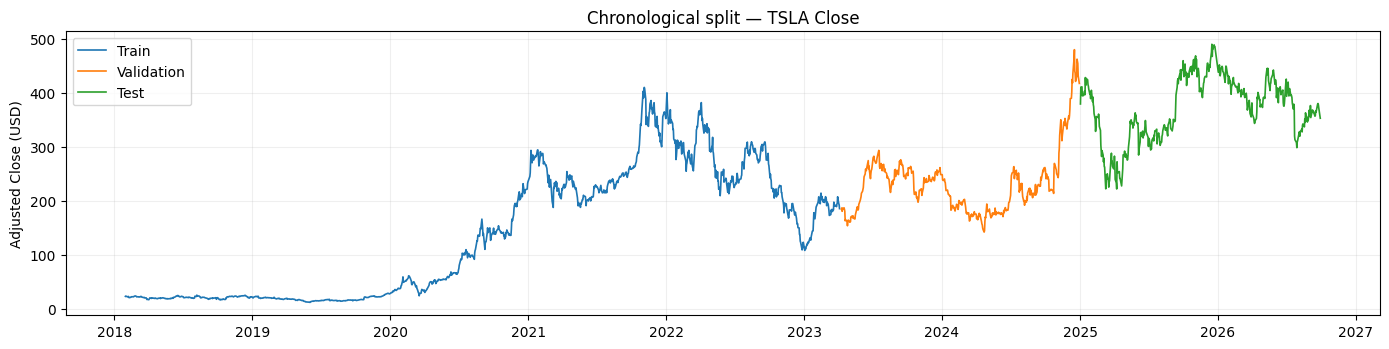

In [6]:
# 특징 관측일을 기준으로 시계열 순서 그대로 나눕니다. shuffle 사용 금지.
n_total = len(data)
cut1, cut2 = int(n_total * 0.60), int(n_total * 0.80)
# 각 구간의 마지막 관측행을 제외: 그 행의 y는 다음 구간에 도달합니다.
train = data.iloc[:cut1-1].copy()
valid = data.iloc[cut1:cut2-1].copy()
test  = data.iloc[cut2:].copy()

X_train, y_train = train[FEATURES], train['Target_Next_Close']
X_valid, y_valid = valid[FEATURES], valid['Target_Next_Close']
X_test, y_test = test[FEATURES], test['Target_Next_Close']
print('Train:', len(train), train.index.min().date(), '-', train.index.max().date())
print('Valid:', len(valid), valid.index.min().date(), '-', valid.index.max().date())
print('Test :', len(test), test.index.min().date(), '-', test.index.max().date())

plt.figure(figsize=(14, 3.6))
plt.plot(train.index, train['Close'], label='Train', lw=1.2)
plt.plot(valid.index, valid['Close'], label='Validation', lw=1.2)
plt.plot(test.index, test['Close'], label='Test', lw=1.2)
plt.title('Chronological split — TSLA Close')
plt.ylabel('Adjusted Close (USD)'); plt.legend(); plt.grid(alpha=.2); plt.tight_layout(); plt.show()

## 5. OLS·Ridge·Lasso·Elastic Net 모델과 검증기간 선택

모델 조건을 공정하게 맞추기 위해 **같은 특징, 같은 목표, 같은 날짜**를 사용합니다.

**비교 모형:**

1. Naïve (다음 거래일 종가 = 당일 종가)
2. OLS / Linear Regression (벌점 없음)
3. Ridge (L2)
4. Lasso (L1)
5. Elastic Net (L1 + L2)

OLS는 검증기간 성능을 기록하되 선택할 하이퍼파라미터가 없습니다. Ridge/Lasso/Elastic Net은 Train으로 적합 후 Validation MAE가 최소인 설정을 선택합니다. **Test는 여기서 보지 않습니다.**

In [7]:
# 다른 모델 간 alpha의 동일한 숫자는 같은 정규화 강도를 의미하지 않습니다.
# 각 모델은 자신의 후보에서만 검증합니다. Lasso/ElasticNet의 수렴을 위해 max_iter를 높입니다.
ALPHAS = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

def make_pipeline(regressor):
    return Pipeline([('scale', StandardScaler()), ('model', regressor)])

candidates = {
    'OLS': [('no_penalty', make_pipeline(LinearRegression()))],
    'Ridge': [(f'alpha={a}', make_pipeline(Ridge(alpha=a))) for a in ALPHAS],
    'Lasso': [(f'alpha={a}', make_pipeline(Lasso(alpha=a, max_iter=30000))) for a in ALPHAS],
    'Elastic Net': [
        (f'alpha={a},l1_ratio={r}', make_pipeline(ElasticNet(alpha=a, l1_ratio=r, max_iter=30000)))
        for a in ALPHAS for r in [0.2, 0.5, 0.8]
    ],
}

selected = {}
validation_rows = []
for family, setups in candidates.items():
    best_mae = float('inf')
    for setting, estimator in setups:
        fitted = clone(estimator).fit(X_train, y_train)
        pred = fitted.predict(X_valid)
        score = mean_absolute_error(y_valid, pred)
        validation_rows.append([family, setting, score])
        if score < best_mae:
            best_mae = score
            selected[family] = {'setting':setting, 'model':clone(estimator), 'validation_mae':score}

selection_table = pd.DataFrame([
    {'Model':name, 'Selected setting':s['setting'], 'Validation MAE':s['validation_mae']}
    for name,s in selected.items()
]).sort_values('Validation MAE')
display(selection_table.round(4))
print('Selection finished using Train + Validation only; test values were not used.')

,Model,Selected setting,Validation MAE
2,Lasso,alpha=0.01,6.1626
0,OLS,no_penalty,6.1627
1,Ridge,alpha=0.001,6.1627
3,Elastic Net,"alpha=0.001,l1_ratio=0.8",6.1633


Selection finished using Train + Validation only; test values were not used.


### 검증결과 해석

- 검증 MAE가 낮다고 반드시 최종 테스트 MAE가 가장 낮지는 않습니다.
- 규제강도 `alpha`가 지나치게 크면 중요 정보까지 축소되어 **과소적합**할 수 있습니다.
- `alpha`가 0에 가까우면 규제효과가 약해집니다.
- `Lasso/Elastic Net`의 0계수는 변수선택 가능성을 보여주지만, 상관된 변수의 선택은 불안정할 수 있습니다.

## 6. Train + Validation 재학습 후, Test 외표본 평가

검증으로 선택한 설정을 **Train + Validation**으로 새로 학습한 뒤, 아직 사용하지 않은 Test에 적용합니다.

- 평가 지표: MAE, RMSE, R²
- 기준모형: `Naïve = Close(t)`
- 주의: **주가 수준(level)의 R²가 높더라도 투자수익이나 방향 예측력이 높다는 의미는 아닙니다.**

검증 구간의 마지막 행도 다음 구간으로 목표가 넘어가기 때문에 재학습에서 제외합니다.

In [8]:
# Train+Validation 사용 가능 행을 합치되, 검증 마지막 행은 제외되어 있습니다.
# 모델의 scaler 역시 이 재학습 데이터에서 새로 fit되므로 테스트 통계가 유입되지 않습니다.
train_valid = pd.concat([train, valid]).sort_index()
X_tv, y_tv = train_valid[FEATURES], train_valid['Target_Next_Close']

predictions = pd.DataFrame(index=X_test.index)
predictions['Actual'] = y_test
predictions['Naive'] = X_test['Close'].values
fitted_models = {}
for name, obj in selected.items():
    model = clone(obj['model']).fit(X_tv, y_tv)
    predictions[name] = model.predict(X_test)
    fitted_models[name] = model

# 평가기간과 행 정렬이 전 모형에서 일치하는지 검사합니다.
assert predictions.notna().all().all()
assert len(predictions) == len(test)

def evaluate(y_true, y_pred):
    return {'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'R2': r2_score(y_true, y_pred)}

metrics_rows = []
for name in ['Naive','OLS','Ridge','Lasso','Elastic Net']:
    metrics_rows.append({'Model':name, **evaluate(predictions['Actual'], predictions[name])})
results = pd.DataFrame(metrics_rows).set_index('Model').sort_values('MAE')
display(results.round(4))

naive_mae = results.loc['Naive','MAE']
results['MAE Skill vs Naive (%)'] = (1 - results['MAE']/naive_mae)*100
print('Positive skill: better than Naive; negative skill: worse than Naive')
display(results.round(3))

,MAE,RMSE,R2
Model,,,
OLS,9.2729,12.1705,0.9585
Ridge,9.2729,12.1705,0.9585
Naive,9.2734,12.1764,0.9585
Elastic Net,9.2738,12.1698,0.9585
Lasso,9.2739,12.1691,0.9585


Positive skill: better than Naive; negative skill: worse than Naive


,MAE,RMSE,R2,MAE Skill vs Naive (%)
Model,,,,
OLS,9.273,12.170,0.959,0.005
Ridge,9.273,12.170,0.959,0.005
Naive,9.273,12.176,0.958,0.000
Elastic Net,9.274,12.170,0.959,-0.004
Lasso,9.274,12.169,0.959,-0.006


## 7. 예측 경로와 모형 간 작은 차이를 함께 시각화하기

주가 수준은 직전 종가에 크게 영향을 받기 때문에 **OLS·Ridge·Lasso·Elastic Net 예측선이 거의 겹치는 것이 자연스러울 수 있습니다.** 겹친다는 사실만으로 코드 오류나 동일한 성능이라고 판단하지 않습니다.

아래 그래프는 네 가지 관점으로 확인합니다.

1. **최근 30개 평가 관측치의 예측 경로:** 실제 종가와 모형들의 전체 움직임 비교
2. **실제값 − 예측값:** 관측일별 예측오차를 비교하며, 0에 가까울수록 해당 관측일의 오차가 작음
3. **각 모형 예측 − Naïve 예측:** 기준모형과의 예측 차이를 확대해 표시 (0은 Naïve와 같은 예측을 의미)
4. **전체 테스트 MAE·RMSE:** 그래프의 겹침과 별도로 실제 외표본 정확도를 정량 평가

**주의:** 모형 간 예측 차이가 크다고 반드시 좋은 모형은 아닙니다. 반드시 실제값과의 오차를 함께 확인해야 합니다.


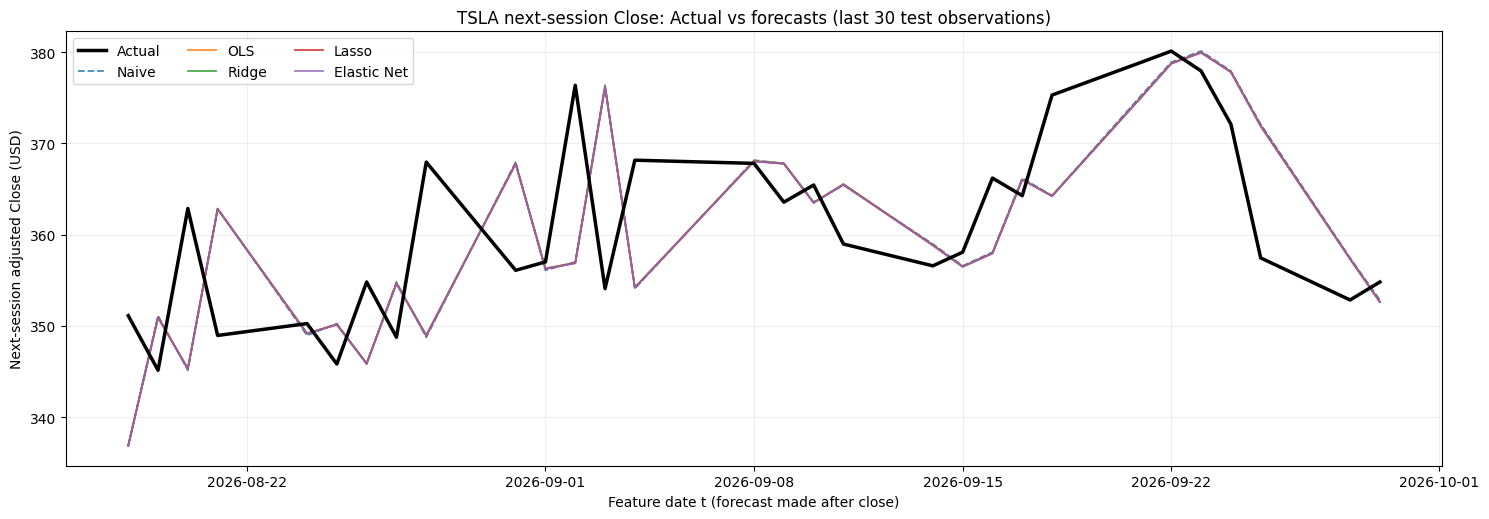

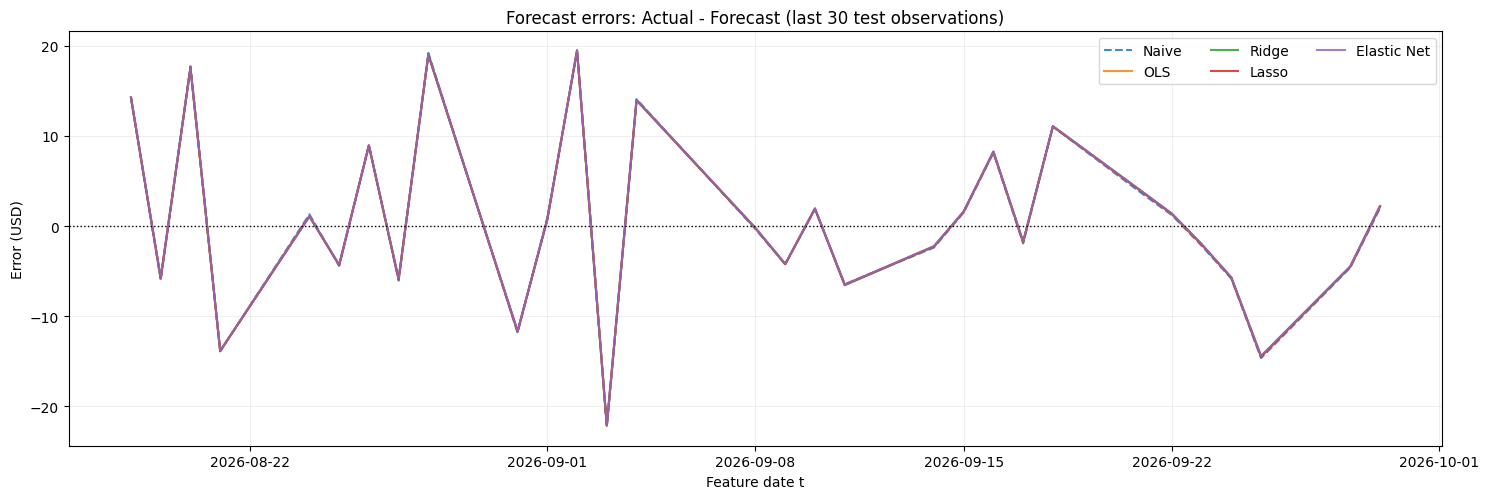

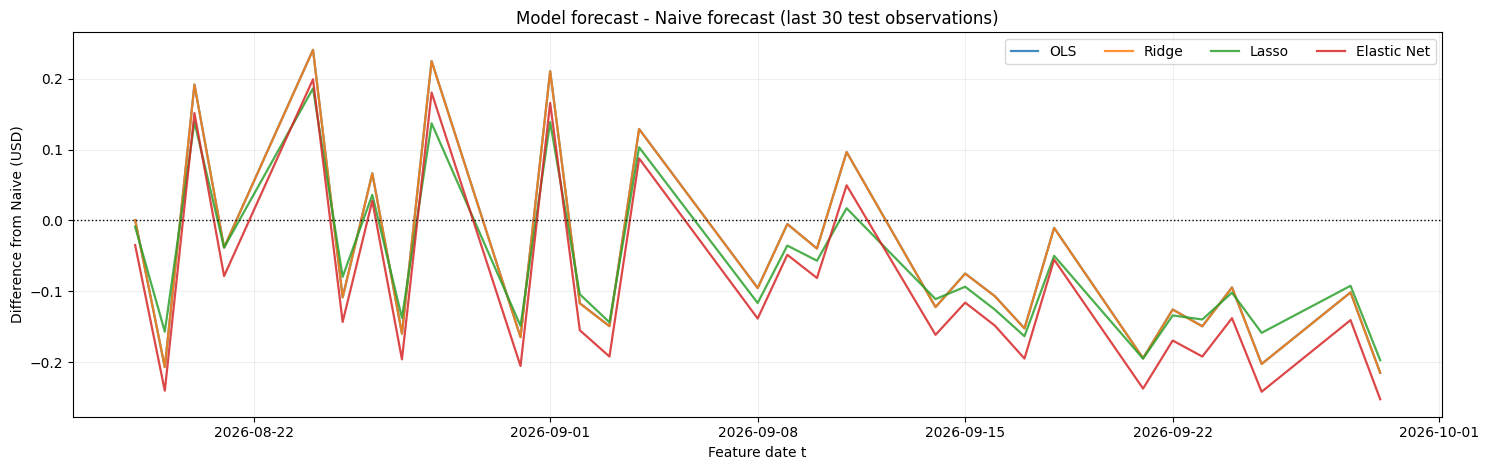

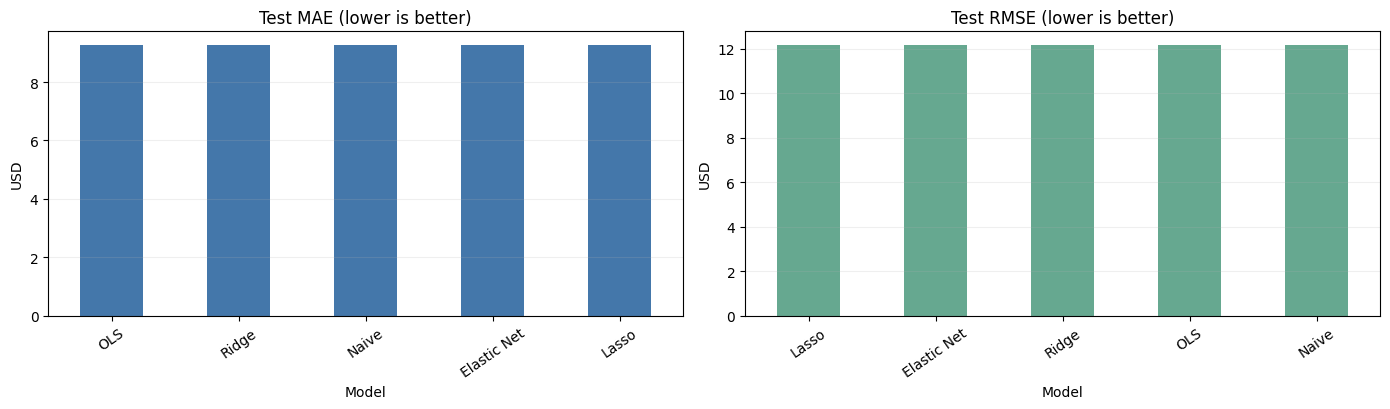

Mean absolute difference between model forecasts (USD):


,OLS,Ridge,Lasso,Elastic Net
OLS,0.0000,0.0001,0.0411,0.0437
Ridge,0.0001,0.0000,0.0411,0.0436
Lasso,0.0411,0.0411,0.0000,0.0473
Elastic Net,0.0437,0.0436,0.0473,0.0000


In [9]:
# [차트 1] 원래 예측 경로 비교는 유지하되 최근 30개 관측치로 확대합니다.
# 주가 수준(예: 수백 USD)에 비해 모델 간 차이(예: 수 USD)가 작으면 선이 겹쳐 보일 수 있습니다.
# 이 현상 자체는 오류가 아니므로, 아래의 오차/Naive 차이 차트와 함께 해석합니다.
plot_data = predictions.tail(30).copy()
model_names = ['Naive', 'OLS', 'Ridge', 'Lasso', 'Elastic Net']

fig, ax = plt.subplots(figsize=(15, 5.3), facecolor='white')
ax.set_facecolor('white')
ax.plot(plot_data.index, plot_data['Actual'], label='Actual', lw=2.5, color='black', zorder=5)
for name in model_names:
    ax.plot(plot_data.index, plot_data[name], label=name,
            linestyle='--' if name == 'Naive' else '-', linewidth=1.3, alpha=.85)
ax.set_title('TSLA next-session Close: Actual vs forecasts (last 30 test observations)')
ax.set_xlabel('Feature date t (forecast made after close)')
ax.set_ylabel('Next-session adjusted Close (USD)')
ax.grid(alpha=.2); ax.legend(ncol=3); plt.tight_layout(); plt.show()

# [차트 2] 실제값을 빼서 추세를 제거한 예측오차를 표시합니다.
# 양(+)의 오차: 실제값이 예측보다 높음 (과소예측), 음(-)의 오차: 실제값이 더 낮음 (과대예측)
# 실제값과 예측값의 동일 날짜 정렬은 앞선 predictions 표에서 이미 검증했습니다.
errors = pd.DataFrame({name: predictions['Actual'] - predictions[name]
                       for name in model_names}, index=predictions.index)
fig, ax = plt.subplots(figsize=(15, 5.1), facecolor='white')
ax.set_facecolor('white')
for name in model_names:
    ax.plot(errors.tail(30).index, errors[name].tail(30), label=name,
            ls='--' if name == 'Naive' else '-', lw=1.5, alpha=.85)
ax.axhline(0, color='black', ls=':', lw=1)
ax.set_title('Forecast errors: Actual - Forecast (last 30 test observations)')
ax.set_ylabel('Error (USD)'); ax.set_xlabel('Feature date t')
ax.grid(alpha=.2); ax.legend(ncol=3); plt.tight_layout(); plt.show()

# [차트 3] Naive와 거의 겹치는 모델 예측선을 분리해 보기 위해
# 각 모델의 예측값에서 같은 시점 Naive 예측값을 뺍니다.
# 0은 Naive와 동일한 예측이며, 0에서 멀수록 Naive와 다른 예측입니다.
# 이 그래프만으로 성능 향상을 뜻하지는 않습니다.
deviation = predictions[['OLS','Ridge','Lasso','Elastic Net']].sub(predictions['Naive'], axis=0)
fig, ax = plt.subplots(figsize=(15, 4.8), facecolor='white')
ax.set_facecolor('white')
for name in deviation.columns:
    ax.plot(deviation.tail(30).index, deviation[name].tail(30), label=name, lw=1.6, alpha=.85)
ax.axhline(0, color='black', ls=':', lw=1)
ax.set_title('Model forecast - Naive forecast (last 30 test observations)')
ax.set_xlabel('Feature date t'); ax.set_ylabel('Difference from Naive (USD)')
ax.grid(alpha=.2); ax.legend(ncol=4); plt.tight_layout(); plt.show()

# [차트 4] 테스트 전체 관측치를 기준으로 실제 오차 지표를 비교합니다.
# 차트가 겹치더라도 MAE, RMSE와 Naive 대비 Skill에서 차이가 날 수 있습니다.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), facecolor='white')
results['MAE'].sort_values().plot.bar(ax=axes[0], color='#4477aa')
axes[0].set_title('Test MAE (lower is better)'); axes[0].set_ylabel('USD')
results['RMSE'].sort_values().plot.bar(ax=axes[1], color='#66a890')
axes[1].set_title('Test RMSE (lower is better)'); axes[1].set_ylabel('USD')
for ax in axes:
    ax.set_facecolor('white')
    ax.tick_params(axis='x', rotation=35)
    ax.grid(axis='y', alpha=.2)
plt.tight_layout(); plt.show()

# [숫자 비교] 네 회귀모형 예측이 실제로 얼마나 비슷한지 정량화합니다.
# 두 예측의 평균 절대 차이(MAD)는 예측값 간 차이이지 정확도 지표는 아닙니다.
regression_names = ['OLS','Ridge','Lasso','Elastic Net']
pairwise = pd.DataFrame(index=regression_names, columns=regression_names, dtype=float)
for a in regression_names:
    for b in regression_names:
        pairwise.loc[a, b] = np.mean(np.abs(predictions[a] - predictions[b]))
print('Mean absolute difference between model forecasts (USD):')
display(pairwise.round(4))


### 결과 해석 질문

1. 주가 경로 그래프에서 네 회귀모형의 선이 겹치는 이유는 무엇입니까? (예: 당일 종가가 강력한 예측변수)
2. **모델 예측 − Naïve** 그래프에서 네 회귀모형이 동일한 값으로 나타납니까, 아니면 작은 차이가 존재합니까?
3. 모델의 예측값이 서로 다르다는 것과 **실제 예측 정확도가 더 높다**는 것은 어떻게 다릅니까?
4. 동일한 Test 구간의 MAE·RMSE를 보고 Naïve보다 개선된 모델이 있는지 확인하세요.
5. 마지막 예측값 간 평균 절대 차이 표에서 OLS와 정규화 모형이 어느 정도 다른지 확인하세요.

**해석상 주의:** 정규화(Ridge/Lasso/Elastic Net)는 모델 계수를 제어하는 방법이지만, 주가 예측에서 반드시 서로 다른 경로나 우수한 성능을 만들지는 않습니다. 정규화 효과 자체는 다음 장의 **표준화된 회귀계수 비교**에서 더 분명하게 관찰할 수 있습니다.


## 8. 계수 축소와 변수선택 비교

`StandardScaler` 이후에 학습된 **표준화된 특징의 계수**를 시각화합니다.

- Ridge: 보통 0에 가까워지지만 반드시 0은 아닙니다.
- Lasso: 일부 계수를 정확히 0으로 만들 수 있습니다.
- Elastic Net: 변수선택과 계수축소를 병행합니다.

주의: 서로 상관성이 강한 특징이 포함되어 있고, 예측대상 가격의 단위가 유지되므로 계수 크기를 인과효과로 해석하지 않습니다.

,OLS,Ridge,Lasso,Elastic Net
Close,111.8497,111.8496,111.8415,111.8265
Return_1,-0.2664,-0.2664,-0.2043,-0.2614
Return_5,-0.3485,-0.3485,-0.2290,-0.3394
MA_5_Ratio,0.2939,0.2939,0.1709,0.2836
MA_20_Ratio,0.4103,0.4103,0.3674,0.4092
Volatility_10,0.0434,0.0434,0.0280,0.0418
Volume_Ratio_5,-0.0107,-0.0107,-0.0021,-0.0104


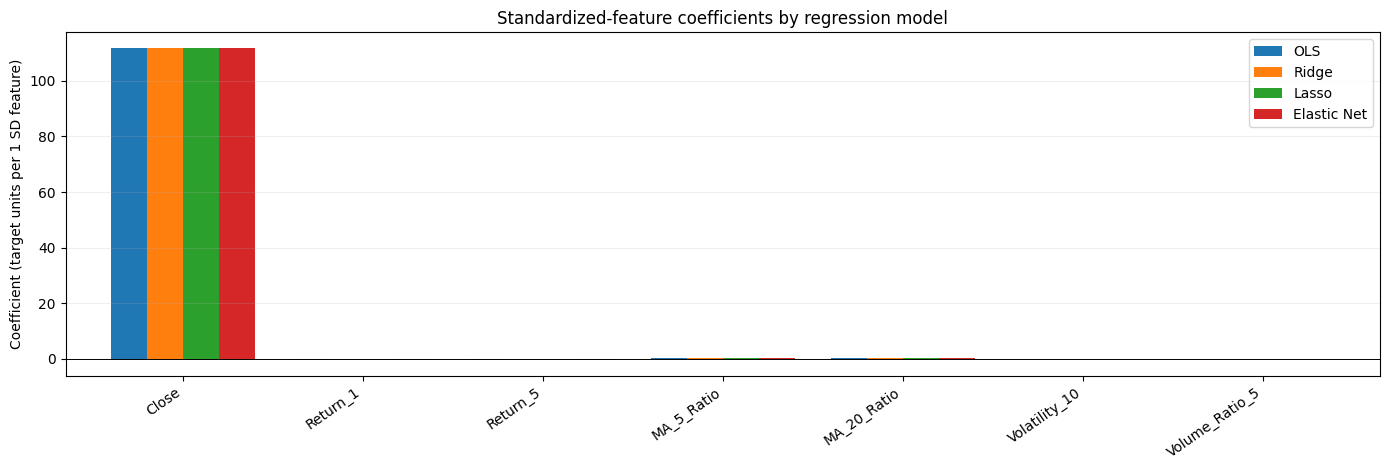

Number of zero coefficients (absolute value < 1e-8):
OLS            0
Ridge          0
Lasso          0
Elastic Net    0


In [10]:
coefs = pd.DataFrame({name: fitted_models[name].named_steps['model'].coef_
                      for name in ['OLS','Ridge','Lasso','Elastic Net']}, index=FEATURES)
display(coefs.round(4))
ax = coefs.plot(kind='bar', figsize=(14, 4.8), width=.8)
ax.set_title('Standardized-feature coefficients by regression model')
ax.set_ylabel('Coefficient (target units per 1 SD feature)')
ax.axhline(0, color='black', lw=.7)
ax.grid(axis='y', alpha=.2)
plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show()
print('Number of zero coefficients (absolute value < 1e-8):')
print((coefs.abs() < 1e-8).sum().to_string())

## 9. 규제강도와 학습·검증 오차: 편향–분산 직관

단순 Ridge를 예시로 `alpha`를 변화시키며 **Train MAE**와 **Validation MAE**가 어떻게 바뀌는지 봅니다.

이 그래프는 **테스트 데이터를 사용하지 않습니다.** 앞의 모델 선택 과정을 설명하기 위한 추가 시각화이며, 검증점수의 최저값이 테스트 최적값을 보장하지 않습니다.

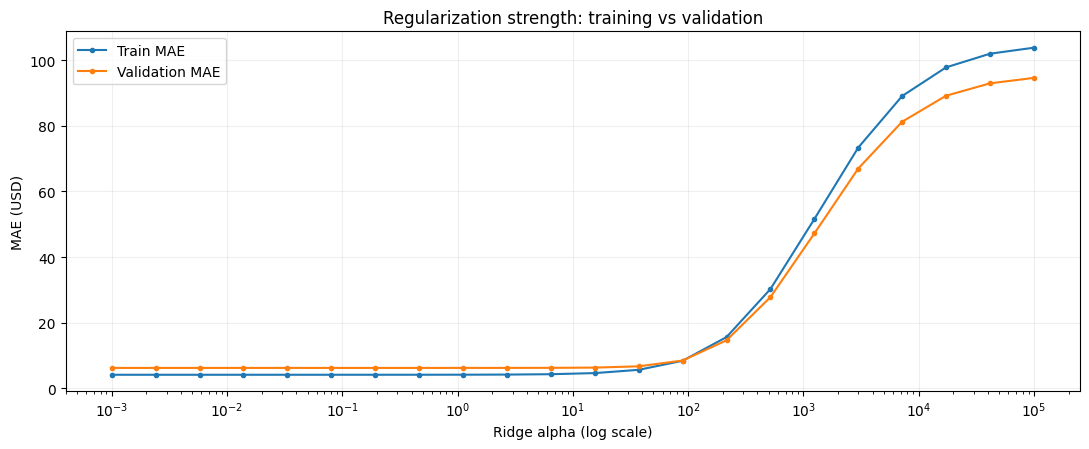

In [11]:
ridge_alpha_grid = np.logspace(-3, 5, 22)
train_errors, valid_errors = [], []
for alpha in ridge_alpha_grid:
    model = make_pipeline(Ridge(alpha=alpha)).fit(X_train, y_train)
    train_errors.append(mean_absolute_error(y_train, model.predict(X_train)))
    valid_errors.append(mean_absolute_error(y_valid, model.predict(X_valid)))
plt.figure(figsize=(11, 4.6))
plt.semilogx(ridge_alpha_grid, train_errors, marker='o', ms=3, label='Train MAE')
plt.semilogx(ridge_alpha_grid, valid_errors, marker='o', ms=3, label='Validation MAE')
plt.xlabel('Ridge alpha (log scale)'); plt.ylabel('MAE (USD)')
plt.title('Regularization strength: training vs validation')
plt.grid(alpha=.2); plt.legend(); plt.tight_layout(); plt.show()

## 10. 종합 정리 및 연구·실무적 주의점

| 모형 | 벌점 | 기대 효과 | 주의점 |
|---|---|---|---|
| OLS | 없음 | 가장 기본적인 비교 회귀 | 다중공선성·과적합 가능 |
| Ridge | L2 | 계수 안정화·축소 | 변수선택(0계수)에는 제한 |
| Lasso | L1 | 불필요한 변수 제거 가능 | 상관 특징 중 선택 불안정 |
| Elastic Net | L1+L2 | 축소와 변수선택의 절충 | `alpha`와 `l1_ratio` 튜닝 필요 |
| Naïve | 없음 | 강력하고 해석 쉬운 기준선 | 복잡한 관계를 직접 모델링하지 않음 |

**이번 실습의 핵심 결론**

1. Underfit/Overfit은 모형 이름이 아니라 **학습오차와 새로운 자료의 예측오차**를 비교해 판단합니다.
2. 정규화는 과적합 위험을 낮추는 방법이지만 **항상 예측 성능을 개선하는 것은 아닙니다.**
3. 하이퍼파라미터 선택은 검증기간에서, 최종 성능 보고는 독립된 테스트기간에서 합니다.
4. `Naïve = Close(t)`는 TSLA 하루 앞 종가 예측에서 필수 기준선입니다.
5. 이번 예측 경로는 거래일 `t` 장 마감 후 계산된 값이며, 날짜축은 특징 관측일 `t`입니다. 실제 예측 대상은 다음 거래일입니다.
6. 본 노트북은 **한 번의 60/20/20 분할**을 사용합니다. 연구논문 수준에서는 walk-forward 다중 분할, 다른 시장 레짐, 여러 예측기간, 거래비용 및 수익률 평가가 추가로 필요합니다.

> 참고: 모든 실제 TSLA 수치와 모델 순위는 **Colab에서 다운로드·실행한 결과**에 따라 달라집니다. 본문은 특정 모델이 반드시 우수하다고 주장하지 않습니다.